In [ ]:
# 2. Load PHEME Data from Extracted Source
PHEME_BASE_PATH = r"E:\codewithsenpai\NNDL-PRJ\Amruta\empathy_misinfo_project\data\raw\pheme\extracted\all-rnr-annotated-threads"

records = []

# Iterate through events
for event_folder in os.listdir(PHEME_BASE_PATH):
    event_path = os.path.join(PHEME_BASE_PATH, event_folder)
    if not os.path.isdir(event_path) or event_folder.startswith('.'):
        continue
    
    # Iterate through rumour/non-rumour labels
    for label_type in ['rumours', 'non-rumours']:
        label_type_path = os.path.join(event_path, label_type)
        if not os.path.exists(label_type_path):
            continue
        
        # Determine label based on folder type
        is_rumour = (label_type == 'rumours')
        
        # Iterate through individual rumours
        for rumour_id in os.listdir(label_type_path):
            rumour_path = os.path.join(label_type_path, rumour_id)
            if not os.path.isdir(rumour_path) or rumour_id.startswith('.'):
                continue
            
            # Load annotation
            annotation_file = os.path.join(rumour_path, "annotation.json")
            source_tweets_path = os.path.join(rumour_path, "source-tweets")
            
            if not os.path.exists(annotation_file) or not os.path.exists(source_tweets_path):
                continue
            
            try:
                with open(annotation_file, "r", encoding="utf-8") as f:
                    label_data = json.load(f)
                
                veracity = label_data.get("veracity", "unverified")
            except:
                veracity = "unverified"
            
            # Load source tweets
            for tweet_file in os.listdir(source_tweets_path):
                if tweet_file.startswith('.'):
                    continue
                    
                tweet_path = os.path.join(source_tweets_path, tweet_file)
                try:
                    with open(tweet_path, "r", encoding="utf-8") as f:
                        tweet = json.load(f)
                    
                    records.append({
                        "event": event_folder,
                        "rumour_id": rumour_id,
                        "label_type": label_type,
                        "tweet_id": tweet.get("id_str", ""),
                        "text": tweet.get("text", ""),
                        "veracity": veracity,
                        "is_rumour": is_rumour
                    })
                except Exception as e:
                    pass

pheme_df = pd.DataFrame(records)
print(f"✅ PHEME dataset loaded: {len(pheme_df)} records")
print(f"✅ Events: {pheme_df['event'].nunique()}")
print(f"✅ Rumours: {pheme_df['rumour_id'].nunique()}")
print("\nFirst 5 records:")
pheme_df.head()

✅ PHEME dataset loaded: 6425 records
✅ Events: 9
✅ Rumours: 6425

First 5 records:


,event,rumour_id,label_type,tweet_id,text,veracity,is_rumour
0,charliehebdo-all-rnr-threads,552783238415265792,rumours,552783238415265792,"Breaking: At least 10 dead, 5 injured after tO...",unverified,True
1,charliehebdo-all-rnr-threads,552783667052167168,rumours,552783667052167168,France: 10 people dead after shooting at HQ of...,unverified,True
2,charliehebdo-all-rnr-threads,552783745565347840,rumours,552783745565347840,Ten killed in shooting at headquarters of Fren...,unverified,True
3,charliehebdo-all-rnr-threads,552784168849907712,rumours,552784168849907712,BREAKING: 10 dead in shooting at headquarters ...,unverified,True
4,charliehebdo-all-rnr-threads,552784526955806720,rumours,552784526955806720,Reuters: 10 people shot dead at headquarters o...,unverified,True


In [14]:
# ============================================================
# TASK 1A: PHEME DATASET - EDA & DATA CLEANING
# ============================================================

# 1. Import Libraries
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


In [19]:
# 3. EDA: Dataset Overview & Label Distribution
print("="*60)
print("PHEME DATASET - EXPLORATORY DATA ANALYSIS")
print("="*60)

print("\n📊 Dataset Shape:", pheme_df.shape)
print("\n📋 Column Info:")
pheme_df.info()

# print("\n" + "="*60)
# print("Label Distribution:")
# print("="*60)
# label_counts = pheme_df["label"].value_counts()
# label_pct = pheme_df["label"].value_counts(normalize=True) * 100
# for label in label_counts.index:
#     print(f"{label:15s}: {label_counts[label]:5d} ({label_pct[label]:5.1f}%)")

# print(f"\nClass Imbalance Ratio (True/False):", 
#       f"{label_counts.get('true', 0) / max(label_counts.get('false', 1), 1):.2f}")

print("="*60)
print("Label Distribution (Veracity)")
print("="*60)

label_counts = pheme_df["veracity"].value_counts()
label_pct = pheme_df["veracity"].value_counts(normalize=True) * 100

for label in label_counts.index:
    print(f"{label:15s}: {label_counts[label]:5d} ({label_pct[label]:5.1f}%)")

PHEME DATASET - EXPLORATORY DATA ANALYSIS

📊 Dataset Shape: (6425, 9)

📋 Column Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6425 entries, 0 to 6424
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   event        6425 non-null   object
 1   rumour_id    6425 non-null   object
 2   label_type   6425 non-null   object
 3   tweet_id     6425 non-null   object
 4   text         6425 non-null   object
 5   veracity     6425 non-null   object
 6   is_rumour    6425 non-null   bool  
 7   text_length  6425 non-null   int64 
 8   word_count   6425 non-null   int64 
dtypes: bool(1), int64(2), object(6)
memory usage: 408.0+ KB
Label Distribution (Veracity)
unverified     :  6425 (100.0%)



TEXT PROPERTIES

Text Length Statistics:
count    6425.000000
mean      118.047315
std        23.501271
min        17.000000
25%       105.000000
50%       127.000000
75%       137.000000
max       152.000000
Name: text_length, dtype: float64


Word Count Statistics:
count    6425.000000
mean       16.151128
std         4.583395
min         3.000000
25%        13.000000
50%        16.000000
75%        19.000000
max        31.000000
Name: word_count, dtype: float64


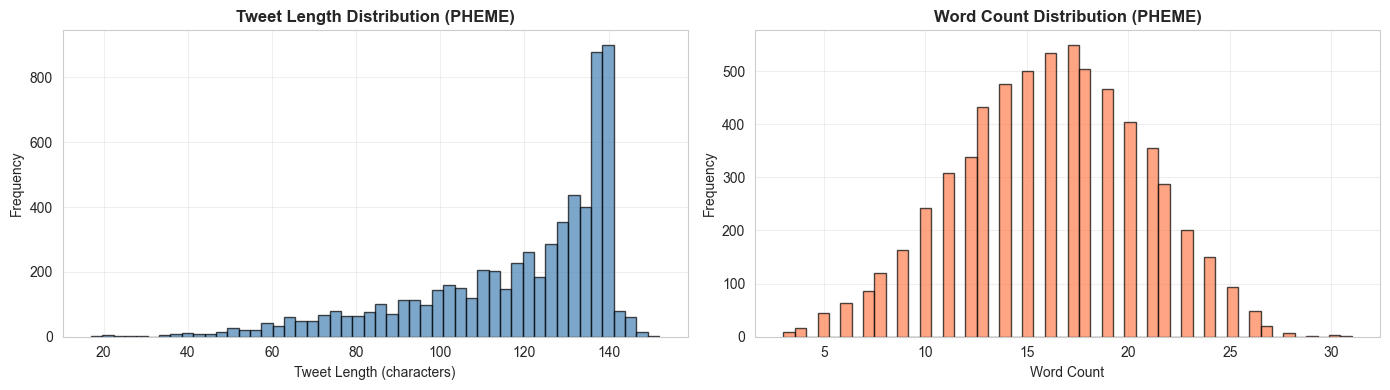


✅ Text properties analyzed


In [20]:
# 4. EDA: Text Properties Analysis
print("\n" + "="*60)
print("TEXT PROPERTIES")
print("="*60)

pheme_df["text_length"] = pheme_df["text"].str.len()
pheme_df["word_count"] = pheme_df["text"].str.split().str.len()

print("\nText Length Statistics:")
print(pheme_df["text_length"].describe())

print("\n\nWord Count Statistics:")
print(pheme_df["word_count"].describe())

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(pheme_df["text_length"], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel("Tweet Length (characters)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Tweet Length Distribution (PHEME)", fontweight='bold')
axes[0].grid(alpha=0.3)

axes[1].hist(pheme_df["word_count"], bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_xlabel("Word Count")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Word Count Distribution (PHEME)", fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Text properties analyzed")

In [21]:
# 5. Data Cleaning: Text Preprocessing
print("\n" + "="*60)
print("DATA CLEANING - TEXT PREPROCESSING")
print("="*60)

def clean_text(text):
    """
    Clean text by:
    1. Converting to lowercase
    2. Removing URLs
    3. Removing mentions (@user)
    4. Removing hashtag symbols (keep text)
    5. Removing special characters (keep alphanumeric + spaces)
    """
    if not isinstance(text, str):
        return ""
    
    text = text.lower()
    text = re.sub(r"http\S+", "", text)           # URLs
    text = re.sub(r"www\S+", "", text)            # www links
    text = re.sub(r"@\w+", "", text)              # mentions
    text = re.sub(r"#", "", text)                 # hashtag symbols
    text = re.sub(r"[^a-z\s]", "", text)          # special characters
    text = re.sub(r"\s+", " ", text)              # extra spaces
    return text.strip()

print("\n🔄 Applying cleaning function...")
pheme_df["clean_text"] = pheme_df["text"].apply(clean_text)

# Check before/after
print("\n📌 Before Cleaning (sample):")
print(pheme_df["text"].iloc[0][:100])
print("\n📌 After Cleaning:")
print(pheme_df["clean_text"].iloc[0][:100])

# Remove empty tweets
initial_count = len(pheme_df)
pheme_df = pheme_df[pheme_df["clean_text"].str.len() > 5]
removed_count = initial_count - len(pheme_df)

print(f"\n⚠️  Removed {removed_count} tweets with length ≤ 5 characters")
print(f"✅ Final dataset size: {len(pheme_df)} records")

pheme_df["clean_text_length"] = pheme_df["clean_text"].str.len()
pheme_df["clean_word_count"] = pheme_df["clean_text"].str.split().str.len()

print("\nCleaned Text Statistics:")
print(pheme_df["clean_text_length"].describe())


DATA CLEANING - TEXT PREPROCESSING

🔄 Applying cleaning function...

📌 Before Cleaning (sample):
Breaking: At least 10 dead, 5 injured after tO gunman open fire in offices of Charlie  Hebdo,satiric

📌 After Cleaning:
breaking at least dead injured after to gunman open fire in offices of charlie hebdosatirical mag th

⚠️  Removed 0 tweets with length ≤ 5 characters
✅ Final dataset size: 6425 records

Cleaned Text Statistics:
count    6425.000000
mean       90.975253
std        26.423770
min        10.000000
25%        73.000000
50%        91.000000
75%       110.000000
max       142.000000
Name: clean_text_length, dtype: float64


In [26]:
# 6. Data Cleaning: Final Text Normalization
print("\n" + "="*60)
print("FINAL TEXT NORMALIZATION (MODEL-READY)")
print("="*60)

# Keep cleaned text as-is for BERT (no aggressive stemming)
pheme_df["final_text"] = pheme_df["clean_text"]

print("\n📌 Final Text Sample:")
print(pheme_df["final_text"].iloc[0])

# Check for missing values
print("\n" + "="*60)
print("MISSING VALUES CHECK")
print("="*60)
print(pheme_df.isnull().sum())

# Remove any rows with missing text
# pheme_df = pheme_df.dropna(subset=['final_text', 'label'])
pheme_df = pheme_df.dropna(subset=['final_text', 'veracity'])
print(f"\n✅ Final cleaned dataset size: {len(pheme_df)} records")

# Final statistics
print("\n" + "="*60)
print("FINAL DATASET SUMMARY")
print("="*60)
print(f"Total Records: {len(pheme_df)}")
print(f"Total Events: {pheme_df['event'].nunique()}")
print(f"Total Rumours: {pheme_df['rumour_id'].nunique()}")
print(f"\nLabel Distribution (Final):")
# print(pheme_df["label"].value_counts())
print(pheme_df["veracity"].value_counts())
print(f"\nAvg Text Length: {pheme_df['final_text'].str.len().mean():.0f} chars")
print(f"Avg Word Count: {pheme_df['final_text'].str.split().str.len().mean():.1f} words")


FINAL TEXT NORMALIZATION (MODEL-READY)

📌 Final Text Sample:
breaking at least dead injured after to gunman open fire in offices of charlie hebdosatirical mag that published mohammed cartoons

MISSING VALUES CHECK
event                0
rumour_id            0
label_type           0
tweet_id             0
text                 0
veracity             0
is_rumour            0
text_length          0
word_count           0
clean_text           0
clean_text_length    0
clean_word_count     0
final_text           0
dtype: int64

✅ Final cleaned dataset size: 6425 records

FINAL DATASET SUMMARY
Total Records: 6425
Total Events: 9
Total Rumours: 6425

Label Distribution (Final):
veracity
unverified    6425
Name: count, dtype: int64

Avg Text Length: 91 chars
Avg Word Count: 14.8 words
